Random Forest Classification
Dataset Shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']

Training Samples: 120
Testing Samples: 30

Accuracy: 0.9

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



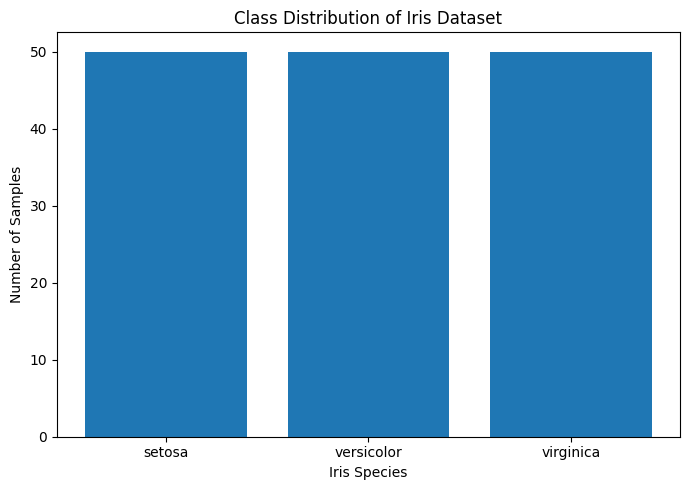

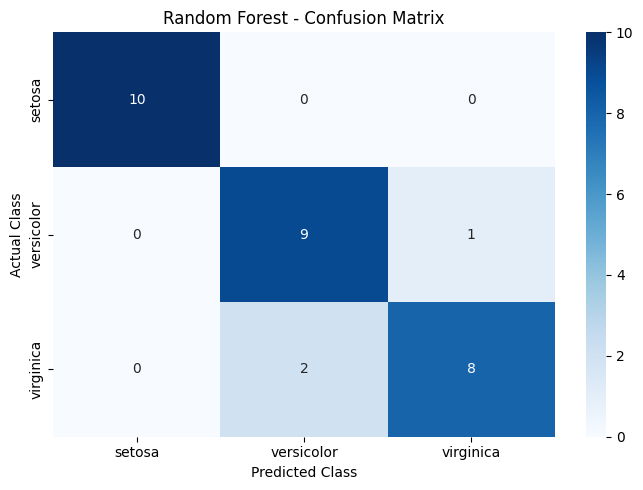

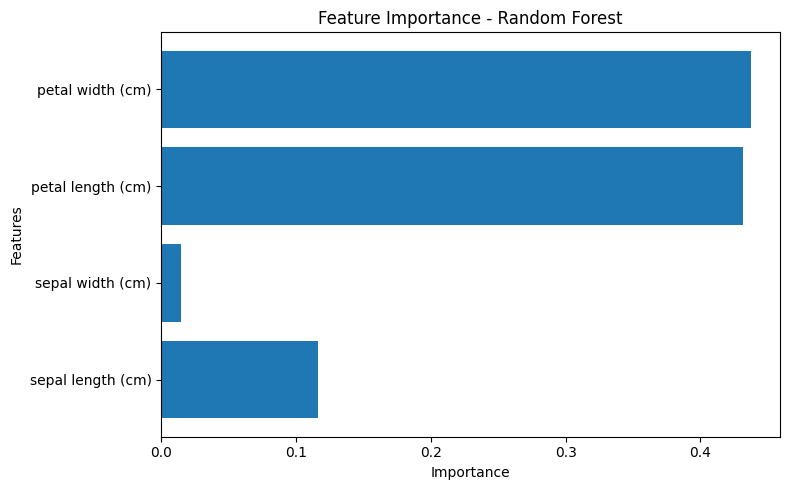


Feature Importance:
-------------------
sepal length (cm): 0.1163
sepal width (cm): 0.0150
petal length (cm): 0.4315
petal width (cm): 0.4372


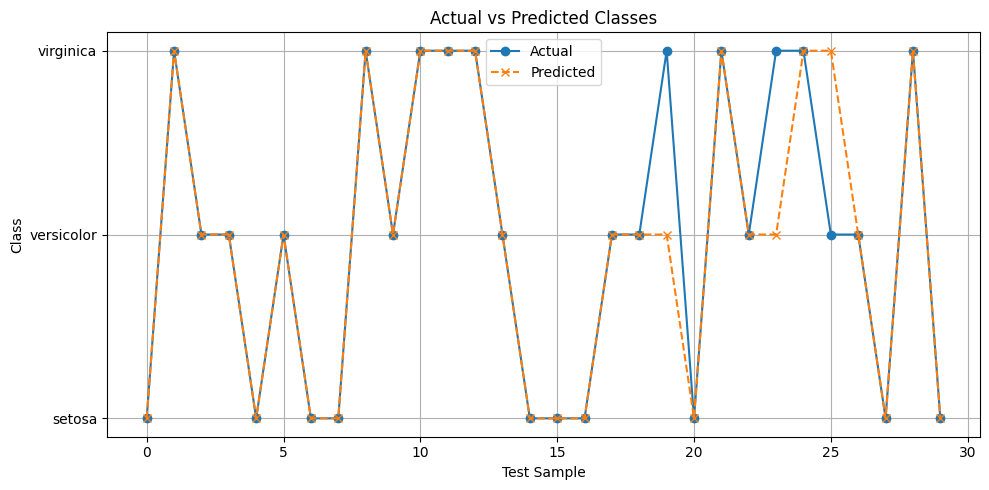

In [1]:
# ============================================================
# RANDOM FOREST CLASSIFICATION
# Dataset : Iris Dataset
# ============================================================

# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names


# Display dataset information
print("Random Forest Classification")
print("============================")
print("Dataset Shape:", X.shape)
print("Features:", feature_names)
print("Classes:", target_names)


# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))


# Create Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    random_state=42
)


# Train the model
model.fit(X_train, y_train)


# Make predictions
y_pred = model.predict(X_test)


# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)


# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# Display classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_names
    )
)


# ============================================================
# PLOT 1: CLASS DISTRIBUTION
# ============================================================

classes, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(7, 5))

plt.bar(
    target_names[classes],
    counts
)

plt.xlabel("Iris Species")
plt.ylabel("Number of Samples")
plt.title("Class Distribution of Iris Dataset")

plt.tight_layout()
plt.show()


# ============================================================
# PLOT 2: CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Random Forest - Confusion Matrix")

plt.tight_layout()
plt.show()


# ============================================================
# PLOT 3: FEATURE IMPORTANCE
# ============================================================

importance = model.feature_importances_

plt.figure(figsize=(8, 5))

plt.barh(
    feature_names,
    importance
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Random Forest")

plt.tight_layout()
plt.show()


# Display feature importance values
print("\nFeature Importance:")
print("-------------------")

for feature, value in zip(feature_names, importance):
    print(f"{feature}: {value:.4f}")


# ============================================================
# PLOT 4: ACTUAL VS PREDICTED CLASSES
# ============================================================

sample_numbers = range(len(y_test))

plt.figure(figsize=(10, 5))

plt.plot(
    sample_numbers,
    y_test,
    "o-",
    label="Actual"
)

plt.plot(
    sample_numbers,
    y_pred,
    "x--",
    label="Predicted"
)

plt.xlabel("Test Sample")
plt.ylabel("Class")

plt.yticks(
    [0, 1, 2],
    target_names
)

plt.title("Actual vs Predicted Classes")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()